# Face-Based Gender Classification (40% Upper Body Crop)

This notebook:
1. Crops the top 40% of PA-100K images to focus on face/upper body region
2. Trains a EVA-02 based gender classifier on cropped images
3. Compares performance with full-body classification

## Part 1: Setup and Imports

In [1]:
import pandas as pd
import shutil
from pathlib import Path
from tqdm import tqdm
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import timm

# Set seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Please ensure a compatible NVIDIA GPU is installed.")

# ===== H100 GPU Optimizations =====
# TF32 for faster matmul/convolutions with negligible precision loss
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')
# Enable Flash Attention and Memory-Efficient Attention (H100 native)
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)

print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"TF32 enabled: {torch.backends.cuda.matmul.allow_tf32}")
    print(f"Flash SDP enabled: {torch.backends.cuda.flash_sdp_enabled()}")
    print(f"BFloat16 supported: {torch.cuda.is_bf16_supported()}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
GPU: NVIDIA H100 80GB HBM3
GPU Memory: 79.2 GB
TF32 enabled: True
Flash SDP enabled: True
BFloat16 supported: True


In [2]:
# Install timm for advanced models
!pip install timm -q

## Part 2: Upper Body Crop Function

Crop the top 40% of images to focus on face and upper body region for gender classification.

In [3]:
# Upper body crop configuration
CROP_RATIO = 0.40  # Top 40% of the image

def crop_upper_body(image, crop_ratio=CROP_RATIO):
    """
    Crop the top portion of an image to focus on face/upper body.
    
    Args:
        image: PIL Image
        crop_ratio: Fraction of image height to keep from top (default 0.40 = 40%)
    
    Returns:
        Cropped PIL Image
    """
    width, height = image.size
    crop_height = int(height * crop_ratio)
    # Crop from top: (left, top, right, bottom)
    return image.crop((0, 0, width, crop_height))

class UpperBodyCrop:
    """Transform class for upper body cropping"""
    def __init__(self, crop_ratio=CROP_RATIO):
        self.crop_ratio = crop_ratio
    
    def __call__(self, image):
        return crop_upper_body(image, self.crop_ratio)
    
    def __repr__(self):
        return f"UpperBodyCrop(crop_ratio={self.crop_ratio})"

print(f"Upper body crop ratio: {CROP_RATIO*100:.0f}% (top portion of image)")

Upper body crop ratio: 40% (top portion of image)


## Part 3: Image Transforms with Upper Body Cropping

In [4]:
# Optimized transforms for face/upper body images
IMAGE_SIZE = 448

# PA-100K specific normalization
DATA_MEAN = [0.4850, 0.4560, 0.4060]
DATA_STD = [0.2290, 0.2240, 0.2250]

def get_transforms(phase):
    """
    Transform pipeline with upper body cropping.
    Key difference: UpperBodyCrop is applied FIRST to focus on face region.
    """
    if phase == 'train':
        return transforms.Compose([
            # IMPORTANT: Crop upper body FIRST before any other transforms
            UpperBodyCrop(crop_ratio=CROP_RATIO),
            # Then resize the cropped region
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            # Augmentations
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            # #transforms.RandomAffine(
            #     #degrees=0,
            #     translate=(0.05, 0.05),
            #     scale=(0.95, 1.05)
            # ),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.15,
                hue=0.03
            ),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
            transforms.ToTensor(),
            #transforms.RandomErasing(p=0.15, scale=(0.02, 0.1), ratio=(0.5, 2.0)),
            transforms.Normalize(mean=DATA_MEAN, std=DATA_STD)
        ])
    else:
        return transforms.Compose([
            # Crop upper body first
            UpperBodyCrop(crop_ratio=CROP_RATIO),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=DATA_MEAN, std=DATA_STD)
        ])

print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Upper body crop: Top {CROP_RATIO*100:.0f}% of original image")
print(f"Focus area: Face and upper torso")

Image size: 448x448
Upper body crop: Top 40% of original image
Focus area: Face and upper torso


## Part 4: Dataset Loading

In [5]:
# Custom Dataset with error handling
class FaceGenderDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
            label = self.labels[idx]
            if self.transform:
                img = self.transform(img)
            return img, label
        except Exception as e:
            print(f"Warning: Could not load image {self.paths[idx]}: {e}")
            img = Image.new('RGB', (100, 100), (0, 0, 0))  # Placeholder
            label = self.labels[idx]
            if self.transform:
                img = self.transform(img)
            return img, label

In [6]:
# Load dataset from organized structure
def load_organized_dataset(base_dir, split):
    """
    Load dataset from organized structure:
    base_dir/Male/split/*.jpg (label=1)
    base_dir/Female/split/*.jpg (label=0)
    """
    male_dir = os.path.join(base_dir, 'Male', split)
    female_dir = os.path.join(base_dir, 'Female', split)
    
    if not os.path.exists(male_dir) or not os.path.exists(female_dir):
        raise FileNotFoundError(f"One or both directories not found: {male_dir}, {female_dir}")
    
    all_paths, all_labels = [], []
    
    # Load Male images (label=1)
    for img_name in os.listdir(male_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_paths.append(os.path.join(male_dir, img_name))
            all_labels.append(1)
    
    # Load Female images (label=0)
    for img_name in os.listdir(female_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_paths.append(os.path.join(female_dir, img_name))
            all_labels.append(0)
    
    if not all_paths:
        raise ValueError(f"No valid images found in {split} split")
    
    return all_paths, all_labels

In [7]:
# Load train, val, test datasets
# ADJUST THIS PATH to your dataset location
base_dataset_dir = '/kaggle/input/datasets/vivekguptaxcode/pa-100k-gender/pa-100k_gender_split_organized'

train_paths, train_labels = load_organized_dataset(base_dataset_dir, 'train')
val_paths, val_labels = load_organized_dataset(base_dataset_dir, 'val')
test_paths, test_labels = load_organized_dataset(base_dataset_dir, 'test')

print(f"Train: {len(train_paths)} images (Male: {sum(train_labels)}, Female: {len(train_labels) - sum(train_labels)})")
print(f"Val: {len(val_paths)} images (Male: {sum(val_labels)}, Female: {len(val_labels) - sum(val_labels)})")
print(f"Test: {len(test_paths)} images (Male: {sum(test_labels)}, Female: {len(test_labels) - sum(test_labels)})")

Train: 80000 images (Male: 43508, Female: 36492)
Val: 10000 images (Male: 5052, Female: 4948)
Test: 10000 images (Male: 6104, Female: 3896)


In [8]:
# Ensure output directory exists
output_dir = '/kaggle/working/face_model_outputs'
os.makedirs(output_dir, exist_ok=True)

print(f"Output directory: {output_dir}")

Output directory: /kaggle/working/face_model_outputs


## Part 5: Visualize Original vs Cropped Images

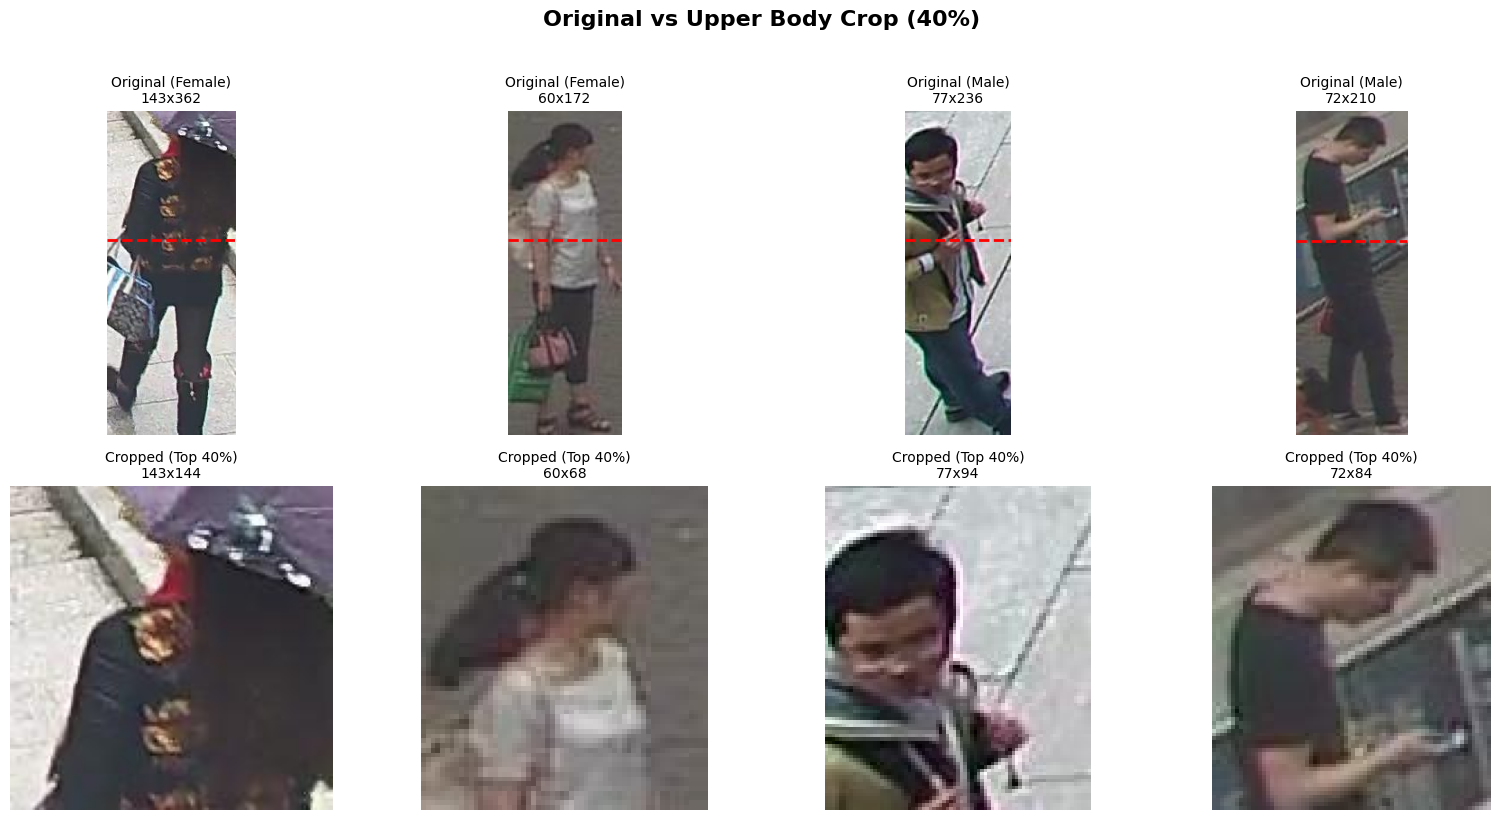


Crop configuration:
  - Crop ratio: 40% from top
  - Focus: Face and upper body region
  - Rationale: Facial features are strong gender indicators


In [9]:
# Visualize the cropping effect
import matplotlib.pyplot as plt
from PIL import Image
import random

# Select random samples
num_samples = 4
random.seed(42)

# Get random indices
female_indices = [i for i, label in enumerate(train_labels) if label == 0]
male_indices = [i for i, label in enumerate(train_labels) if label == 1]

sample_indices = random.sample(female_indices, 2) + random.sample(male_indices, 2)

# Create figure showing original vs cropped
fig, axes = plt.subplots(2, num_samples, figsize=(16, 8))
fig.suptitle(f'Original vs Upper Body Crop ({CROP_RATIO*100:.0f}%)', fontsize=16, fontweight='bold', y=1.02)

for i, idx in enumerate(sample_indices):
    # Load original image
    original = Image.open(train_paths[idx]).convert('RGB')
    # Apply crop
    cropped = crop_upper_body(original, CROP_RATIO)
    
    # Get gender label
    gender = 'Female' if train_labels[idx] == 0 else 'Male'
    
    # Plot original
    axes[0, i].imshow(original)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Original ({gender})\n{original.size[0]}x{original.size[1]}', fontsize=10)
    
    # Draw crop region on original
    w, h = original.size
    crop_h = int(h * CROP_RATIO)
    axes[0, i].axhline(y=crop_h, color='red', linestyle='--', linewidth=2)
    
    # Plot cropped
    axes[1, i].imshow(cropped)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Cropped (Top {CROP_RATIO*100:.0f}%)\n{cropped.size[0]}x{cropped.size[1]}', fontsize=10)

axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Upper Body Crop', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'crop_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCrop configuration:")
print(f"  - Crop ratio: {CROP_RATIO*100:.0f}% from top")
print(f"  - Focus: Face and upper body region")
print(f"  - Rationale: Facial features are strong gender indicators")

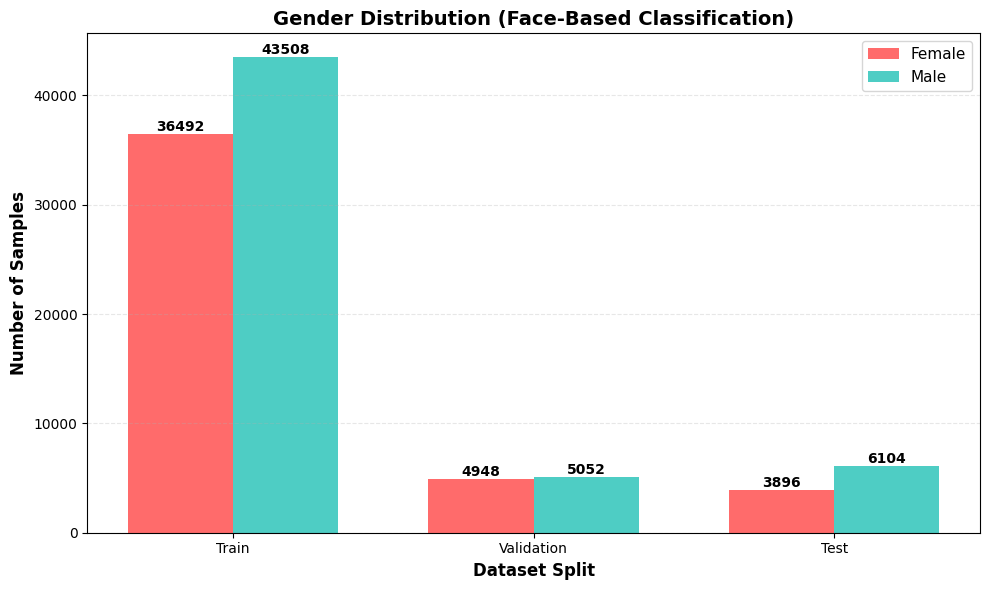

In [10]:
# Visualize dataset distribution
splits = ['Train', 'Validation', 'Test']
male_counts = [sum(train_labels), sum(val_labels), sum(test_labels)]
female_counts = [len(train_labels) - sum(train_labels), 
                 len(val_labels) - sum(val_labels), 
                 len(test_labels) - sum(test_labels)]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(splits))
width = 0.35

bars1 = ax.bar(x - width/2, female_counts, width, label='Female', color='#FF6B6B')
bars2 = ax.bar(x + width/2, male_counts, width, label='Male', color='#4ECDC4')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Dataset Split', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Gender Distribution (Face-Based Classification)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dataset_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

## Part 6: Create DataLoaders

In [11]:
# Create datasets and dataloaders
train_dataset = FaceGenderDataset(train_paths, train_labels, get_transforms('train'))
val_dataset = FaceGenderDataset(val_paths, val_labels, get_transforms('val'))
test_dataset = FaceGenderDataset(test_paths, test_labels, get_transforms('test'))

batch_size = 32  # H100 optimized (80GB VRAM allows larger batches)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                          num_workers=12, pin_memory=True, persistent_workers=True,
                          prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                        num_workers=12, pin_memory=True, persistent_workers=True,
                        prefetch_factor=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                         num_workers=12, pin_memory=True, persistent_workers=True,
                         prefetch_factor=4)

print("DataLoaders created successfully!")
print(f"Batch size: {batch_size} (H100 optimized), Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Upper body crop: {CROP_RATIO*100:.0f}%")

DataLoaders created successfully!
Batch size: 32 (H100 optimized), Image size: 448x448
Upper body crop: 40%


## Part 7: Loss Function and Model Setup

In [12]:
# Compute class weights for imbalanced dataset
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Focal Loss for better handling of hard examples
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.n_classes = 2
    
    def forward(self, inputs, targets):
        n_classes = inputs.size(-1)
        
        with torch.no_grad():
            smooth_targets = torch.zeros_like(inputs)
            smooth_targets.fill_(self.smoothing / (n_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        log_probs = torch.nn.functional.log_softmax(inputs, dim=-1)
        probs = torch.exp(log_probs)
        
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1 - pt) ** self.gamma
        
        ce_loss = -(smooth_targets * log_probs).sum(dim=-1)
        focal_loss = focal_weight * ce_loss
        
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            focal_loss = alpha_t * focal_loss
        
        return focal_loss.mean()

criterion = FocalLoss(alpha=class_weights, gamma=2.0, smoothing=0.05)

print(f"Class weights: {class_weights}")
print(f"Using Focal Loss with gamma=2.0 and label smoothing=0.05")

Class weights: tensor([1.0961, 0.9194], device='cuda:0')
Using Focal Loss with gamma=2.0 and label smoothing=0.05


In [ ]:
# Custom Head for Vision Transformers
class CustomHeadViT(nn.Module):
    def __init__(self, num_ftrs, drop_rate=0.5):
        super().__init__()
        self.norm = nn.LayerNorm(num_ftrs)
        self.drop = nn.Dropout(drop_rate)
        self.fc = nn.Linear(num_ftrs, 2)
    
    def forward(self, x):
        x = self.norm(x)
        x = self.drop(x)
        return self.fc(x)

# EVA-02 Large - Excellent for fine-grained classification like facial features
model = timm.create_model(
    'eva02_large_patch14_448.mim_m38m_ft_in22k_in1k',
    pretrained=True, 
    num_classes=2,
    drop_path_rate=0.4
)

# Enable gradient checkpointing for memory efficiency
model.set_grad_checkpointing(enable=True)

# Replace head with custom head
num_ftrs = model.head.in_features
model.head = CustomHeadViT(num_ftrs, drop_rate=0.5)
model = model.to(device)

torch.cuda.empty_cache()

print(f"Model: EVA-02 Large (eva02_large_patch14_448)")
print(f"Gradient checkpointing: ENABLED")
print(f"H100 optimizations: TF32 + BF16 + Flash Attention")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Input: Upper body crop ({CROP_RATIO*100:.0f}%) resized to {IMAGE_SIZE}x{IMAGE_SIZE}")

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Model: EVA-02 Large (eva02_large_patch14_448)
Gradient checkpointing: ENABLED
torch.compile: ENABLED (H100 optimized)
Total parameters: 304,059,330
Trainable parameters: 304,059,330
Input: Upper body crop (40%) resized to 448x448


## Part 8: Training Utilities

In [14]:
# Early stopping class
class EarlyStopping:
    def __init__(self, patience=5, delta=0.001, mode='max'):
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_metric, model, save_path=None):
        if not isinstance(val_metric, (int, float)) or val_metric is None:
            raise ValueError(f"Invalid val_metric: {val_metric}")
        
        score = val_metric if self.mode == 'max' else -val_metric
        print(f"EarlyStopping: val_metric={val_metric:.4f}, mode={self.mode}, best={self.best_score}")
        
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"Saved model to {save_path}")
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f"EarlyStopping: No improvement. Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
                print("EarlyStopping: Triggered")
        else:
            print(f"EarlyStopping: Improved from {self.best_score:.4f} to {score:.4f}")
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"Saved model to {save_path}")

In [15]:
from copy import deepcopy

# Exponential Moving Average
class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = deepcopy(model)
        self.ema.eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)
    
    def update(self, model):
        with torch.no_grad():
            for ema_p, model_p in zip(self.ema.parameters(), model.parameters()):
                ema_p.data.mul_(self.decay).add_(model_p.data, alpha=1 - self.decay)
    
    def state_dict(self):
        return self.ema.state_dict()
    
    def load_state_dict(self, state_dict):
        self.ema.load_state_dict(state_dict)

def train_one_epoch(model, loader, criterion, optimizer, device, scaler, ema=None, max_grad_norm=1.0):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    progress_bar = tqdm(loader, desc="Training", leave=True)
    
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
        
        if ema is not None:
            ema.update(model)
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        progress_bar.set_postfix({
            'batch_loss': f'{loss.item():.4f}',
            'batch_acc': f'{(100 * (predicted == labels).sum().item() / labels.size(0)):.2f}%'
        })
    
    if total == 0:
        raise ValueError("No samples processed")
    return running_loss / total, 100 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_scores = [], [], []
    progress_bar = tqdm(loader, desc="Validating", leave=True)
    
    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            progress_bar.set_postfix({
                'batch_loss': f'{loss.item():.4f}',
                'batch_acc': f'{(100 * (predicted == labels).sum().item() / labels.size(0)):.2f}%'
            })

    if total == 0:
        raise ValueError("No samples processed")
    return running_loss / total, 100 * correct / total, all_preds, all_labels, all_scores

## Part 9: Phase 1 - Train Head Only (15 epochs)

In [16]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR

# H100: BF16 has same dynamic range as FP32, no gradient scaling needed
scaler = torch.amp.GradScaler('cuda', enabled=False)
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# Phase 1: Train head only
for param in model.parameters():
    param.requires_grad = False
for param in model.head.parameters():
    param.requires_grad = True

optimizer = AdamW(model.head.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = OneCycleLR(optimizer, max_lr=3e-3, epochs=15, steps_per_epoch=len(train_loader),
                       pct_start=0.1, anneal_strategy='cos')
early_stopping = EarlyStopping(patience=5, mode='max')
ema = ModelEMA(model, decay=0.999)

print("Phase 1: Training head (15 epochs) - Face-Based Classification")
print(f"Input: Upper body crop ({CROP_RATIO*100:.0f}%)")
print(f"Mixed precision: BFloat16 (H100 native)")

for epoch in range(15):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, scaler, ema
    )
    val_loss, val_acc, val_preds, val_labels_out, _ = validate(ema.ema, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    scheduler.step()
    
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
        val_labels_out, val_preds, average=None, labels=[0, 1]
    )
    
    print(f'Epoch {epoch+1}/15 (Phase 1 - Face):')  
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% (EMA)')
    print(f'  Female (0) - P: {val_precision[0]:.4f}, R: {val_recall[0]:.4f}, F1: {val_f1[0]:.4f}')
    print(f'  Male (1) - P: {val_precision[1]:.4f}, R: {val_recall[1]:.4f}, F1: {val_f1[1]:.4f}')
    print(f'  LR: {scheduler.get_last_lr()[0]:.6f}')
    
    early_stopping(val_acc, ema.ema, save_path=os.path.join(output_dir, 'best_face_model_phase1.pth'))
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

model.load_state_dict(early_stopping.best_model_state)
print(f"Loaded best model from Phase 1 (best val_acc: {early_stopping.best_score:.2f}%)")

Phase 1: Training head (15 epochs) - Face-Based Classification
Input: Upper body crop (40%)
Mixed precision: BFloat16 (H100 native)


Training:   0%|          | 0/2500 [00:00<?, ?it/s]

BackendCompilerFailed: backend='inductor' raised:
KeyError: '_scaled_dot_product_flash_attention'

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bug to PyTorch). For even more developer context, set TORCH_LOGS="+dynamo"


## Part 10: Phase 2 - Fine-tune Entire Model (50 epochs)

In [ ]:
# Layer-wise learning rate decay for EVA-02
def get_eva02_param_groups(model, base_lr=5e-6, lr_decay=0.85, weight_decay=0.05):
    param_groups = []
    num_blocks = 24
    
    # Patch embedding
    embed_params = [p for n, p in model.named_parameters() 
                    if ('patch_embed' in n or 'cls_token' in n or 'pos_embed' in n) and p.requires_grad]
    if embed_params:
        param_groups.append({
            'params': embed_params,
            'lr': base_lr * (lr_decay ** num_blocks),
            'weight_decay': weight_decay,
            'name': 'embed'
        })
    
    # Transformer blocks
    block_groups = [(0, 6), (6, 12), (12, 18), (18, 24)]
    for group_idx, (start, end) in enumerate(block_groups):
        block_params = []
        for block_idx in range(start, end):
            block_params.extend([p for n, p in model.named_parameters() 
                                if f'blocks.{block_idx}.' in n and p.requires_grad])
        if block_params:
            group_lr = base_lr * (lr_decay ** (3 - group_idx))
            param_groups.append({
                'params': block_params,
                'lr': group_lr,
                'weight_decay': weight_decay,
                'name': f'blocks_{start}-{end-1}'
            })
    
    # Norm layer
    norm_params = [p for n, p in model.named_parameters() 
                   if 'norm' in n and 'head' not in n and 'blocks' not in n and p.requires_grad]
    if norm_params:
        param_groups.append({
            'params': norm_params,
            'lr': base_lr,
            'weight_decay': 0.0,
            'name': 'norm'
        })
    
    # Head
    head_params = [p for n, p in model.named_parameters() if 'head' in n and p.requires_grad]
    if head_params:
        param_groups.append({
            'params': head_params,
            'lr': base_lr * 10,
            'weight_decay': weight_decay,
            'name': 'head'
        })
    
    print("EVA-02 Layer-wise LR groups:")
    total_params = 0
    for pg in param_groups:
        n_params = sum(p.numel() for p in pg['params'])
        total_params += n_params
        print(f"  {pg['name']}: LR={pg['lr']:.2e}, params={n_params:,}")
    print(f"  Total trainable params: {total_params:,}")
    
    return param_groups

In [ ]:
# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

param_groups = get_eva02_param_groups(model, base_lr=5e-6, lr_decay=0.85, weight_decay=0.05)
optimizer = AdamW(param_groups)

total_epochs = 15
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)

early_stopping = EarlyStopping(patience=7, mode='max')
ema = ModelEMA(model, decay=0.999)

print(f"\nPhase 2: Fine-tuning with layer-wise LR ({total_epochs} epochs)")
print(f"Input: Upper body crop ({CROP_RATIO*100:.0f}%) - Face-based classification")

best_val_acc = 0

for epoch in range(total_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, scaler, ema
    )
    val_loss, val_acc, val_preds, val_labels_out, _ = validate(ema.ema, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step()
    
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
        val_labels_out, val_preds, average=None, labels=[0, 1]
    )
    
    gap = train_acc - val_acc
    
    print(f'Epoch {epoch+1}/{total_epochs} (Phase 2 - Face):')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% (EMA)')
    print(f'  Train-Val Gap: {gap:.2f}% {" OVERFITTING" if gap > 5 else "✓"}')
    print(f'  Female (0) - P: {val_precision[0]:.4f}, R: {val_recall[0]:.4f}, F1: {val_f1[0]:.4f}')
    print(f'  Male (1) - P: {val_precision[1]:.4f}, R: {val_recall[1]:.4f}, F1: {val_f1[1]:.4f}')
    print(f'  LR (head): {optimizer.param_groups[-1]["lr"]:.2e}')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(ema.ema.state_dict(), os.path.join(output_dir, 'best_face_model_acc.pth'))
        print(f'   New best accuracy! Saved model.')
    
    early_stopping(val_acc, ema.ema, save_path=os.path.join(output_dir, 'best_face_model_phase2.pth'))
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

model.load_state_dict(early_stopping.best_model_state)
print(f"\nLoaded best model from Phase 2 (best val_acc: {early_stopping.best_score:.2f}%)")

## Part 11: Evaluate on Test Set

In [ ]:
# Test-Time Augmentation with upper body crop
def tta_predict(model, loader, device):
    """
    TTA using original + horizontal flip.
    Note: Upper body crop is already applied in the dataloader transforms.
    """
    model.eval()
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="TTA Prediction"):
            batch_probs = []
            inputs = inputs.to(device, non_blocking=True)
            
            # Original prediction
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
            batch_probs.append(probs.cpu())
            
            # Horizontal flip
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                outputs_flip = model(torch.flip(inputs, dims=[3]))
                probs_flip = torch.softmax(outputs_flip, dim=1)
            batch_probs.append(probs_flip.cpu())
            
            avg_probs = torch.stack(batch_probs).mean(dim=0)
            all_probs.append(avg_probs)
            all_labels.extend(labels.numpy())
    
    all_probs = torch.cat(all_probs, dim=0)
    all_preds = all_probs.argmax(dim=1).numpy()
    all_scores = all_probs[:, 1].numpy()
    
    return all_preds, all_labels, all_scores

In [ ]:
# Evaluate on test set
print("\n" + "="*60)
print("FACE-BASED GENDER CLASSIFICATION TEST RESULTS")
print(f"Input: Upper body crop ({CROP_RATIO*100:.0f}%)")
print("="*60)

print("\nEvaluating with Test-Time Augmentation...")
test_preds, test_labels, test_scores = tta_predict(model, test_loader, device)

test_acc = 100 * np.mean(np.array(test_preds) == np.array(test_labels))
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_labels, test_preds, average=None, labels=[0, 1]
)

print(f'\nTest Accuracy (with TTA): {test_acc:.2f}%')
print(f'Female (0) - Precision: {test_precision[0]:.4f}, Recall: {test_recall[0]:.4f}, F1: {test_f1[0]:.4f}')
print(f'Male (1) - Precision: {test_precision[1]:.4f}, Recall: {test_recall[1]:.4f}, F1: {test_f1[1]:.4f}')

# Without TTA
print("\nEvaluating WITHOUT TTA...")
_, test_acc_no_tta, test_preds_no_tta, test_labels_no_tta, test_scores_no_tta = validate(
    model, test_loader, criterion, device
)
print(f'Test Accuracy (no TTA): {test_acc_no_tta:.2f}%')

# Save final model
final_model_path = os.path.join(output_dir, 'final_face_gender_model.pth')
torch.save(model.state_dict(), final_model_path)
print(f"\nSaved final model to {final_model_path}")

## Part 12: Visualization & Analysis

In [ ]:
# Publication-ready plots
sns.set_style("darkgrid")

# Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='#1f77b4')
plt.plot(val_losses, label='Validation Loss', color='#ff7f0e')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training and Validation Loss (Face-Based, {CROP_RATIO*100:.0f}% Crop)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'loss_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

# Accuracy Curve
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label='Train Accuracy', color='#1f77b4')
plt.plot(val_accs, label='Validation Accuracy', color='#ff7f0e')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title(f'Training and Validation Accuracy (Face-Based, {CROP_RATIO*100:.0f}% Crop)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'accuracy_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Face-Based, {CROP_RATIO*100:.0f}% Crop)')
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='#ff7f0e', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (Face-Based, {CROP_RATIO*100:.0f}% Crop)')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(test_labels, test_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#1f77b4', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (Face-Based, {CROP_RATIO*100:.0f}% Crop)')
plt.legend(loc='lower left')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'pr_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Show misclassified examples
print("\nMisclassified Examples Analysis")
print("="*50)

# Find misclassified indices
misclassified_idx = [i for i in range(len(test_preds)) if test_preds[i] != test_labels[i]]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(test_preds)} ({100*len(misclassified_idx)/len(test_preds):.2f}%)")

# Show some misclassified examples
if len(misclassified_idx) > 0:
    num_show = min(8, len(misclassified_idx))
    fig, axes = plt.subplots(2, num_show//2, figsize=(16, 8))
    fig.suptitle(f'Misclassified Examples (Face-Based, {CROP_RATIO*100:.0f}% Crop)', fontsize=14, fontweight='bold')
    
    random.seed(42)
    sample_misclassified = random.sample(misclassified_idx, num_show)
    
    for i, idx in enumerate(sample_misclassified):
        row = i // (num_show//2)
        col = i % (num_show//2)
        
        # Load and crop image
        img = Image.open(test_paths[idx]).convert('RGB')
        cropped = crop_upper_body(img, CROP_RATIO)
        
        true_label = 'Female' if test_labels[idx] == 0 else 'Male'
        pred_label = 'Female' if test_preds[idx] == 0 else 'Male'
        confidence = test_scores[idx] if test_preds[idx] == 1 else 1 - test_scores[idx]
        
        axes[row, col].imshow(cropped)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})', 
                                  fontsize=9, color='red')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'misclassified_examples.png'), dpi=300, bbox_inches='tight')
    plt.show()

## Part 13: Summary and Comparison

In [ ]:
# Print final summary
print("\n" + "="*60)
print("FACE-BASED GENDER CLASSIFICATION SUMMARY")
print("="*60)
print(f"\nModel: EVA-02 Large")
print(f"Input: Upper body crop ({CROP_RATIO*100:.0f}% from top)")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"\nTest Results (with TTA):")
print(f"  Accuracy: {test_acc:.2f}%")
print(f"  Female F1: {test_f1[0]:.4f}")
print(f"  Male F1: {test_f1[1]:.4f}")
print(f"  AUC-ROC: {roc_auc:.4f}")
print(f"\nModel saved to: {final_model_path}")
print("\n" + "="*60)
print("Key Differences from Body-Based Classification:")
print("  - Uses top 40% of image (face/upper body region)")
print("  - Better for cases where facial features are visible")
print("  - May struggle with occluded faces or back views")
print("  - Complementary to full-body classification")
print("="*60)